# 05 · Visualización de Resultados

Genera las figuras cualitativas para la tesis:
- Mejores y peores predicciones por modelo
- Comparación visual: GT vs predicciones de todos los modelos
- Grad-CAM para SegFormer
- Casos donde transformer supera a CNN y viceversa
- Figuras listas para publicación (alta resolución)

In [1]:
import os
from pathlib import Path

def _detect_env():
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'): return 'kaggle'
    try:
        import google.colab; return 'colab'
    except ImportError: pass
    try: get_ipython(); return 'notebook'
    except NameError: return 'script'

ENV = _detect_env()
if ENV == 'kaggle': ROOT_DIR = Path('/kaggle/working')
elif ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    ROOT_DIR = Path('/content/drive/MyDrive/oct-retina-segmentation')
else:
    _here = Path(globals().get('__file__', './')).resolve()
    ROOT_DIR = _here.parents[1] if _here.suffix == '.py' else _here.parent

EVAL_DIR  = ROOT_DIR / 'evaluation'
CKPT_DIR  = ROOT_DIR / 'checkpoints'
FIGS_DIR  = ROOT_DIR / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
print(f'[ENV] {ENV}  |  FIGS_DIR={FIGS_DIR}')

[ENV] notebook  |  FIGS_DIR=C:\Users\User\oct-retina-segmentation\OCT\VC2\TP_vision_por_computadora_2\figures


In [2]:
import warnings; warnings.filterwarnings('ignore')
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cv2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paleta de colores para las clases
COLORS_9 = ['#000000','#e6194b','#3cb44b','#4363d8',
             '#f58231','#911eb4','#42d4f4','#f032e6','#ffffff']
COLORS_7 = ['#000000','#e6194b','#3cb44b','#4363d8','#f58231','#911eb4','#ffffff']
cmap9 = ListedColormap(COLORS_9)
cmap7 = ListedColormap(COLORS_7)

MODEL_LABELS = {'unet':'U-Net','unetpp':'U-Net++',
                'resnet_unet':'ResNet34-UNet','segformer':'SegFormer-B2'}

# Cargar predicciones guardadas por 03_evaluacion
pred_path = EVAL_DIR / 'predictions_sample.pkl'
if pred_path.exists():
    with open(pred_path, 'rb') as f:
        preds_store = pickle.load(f)
    print(f'[OK] {len(preds_store)} modelos cargados: {list(preds_store.keys())[:4]}')
else:
    print('[WARN] predictions_sample.pkl no encontrado. Correr 03_evaluacion primero.')
    preds_store = {}

print(f'[OK] Device: {DEVICE}')

[OK] 1 modelos cargados: ['unetpp__v1_kaggle_8c']
[OK] Device: cpu


---
## 1 · Comparación visual: todos los modelos sobre los mismos slices

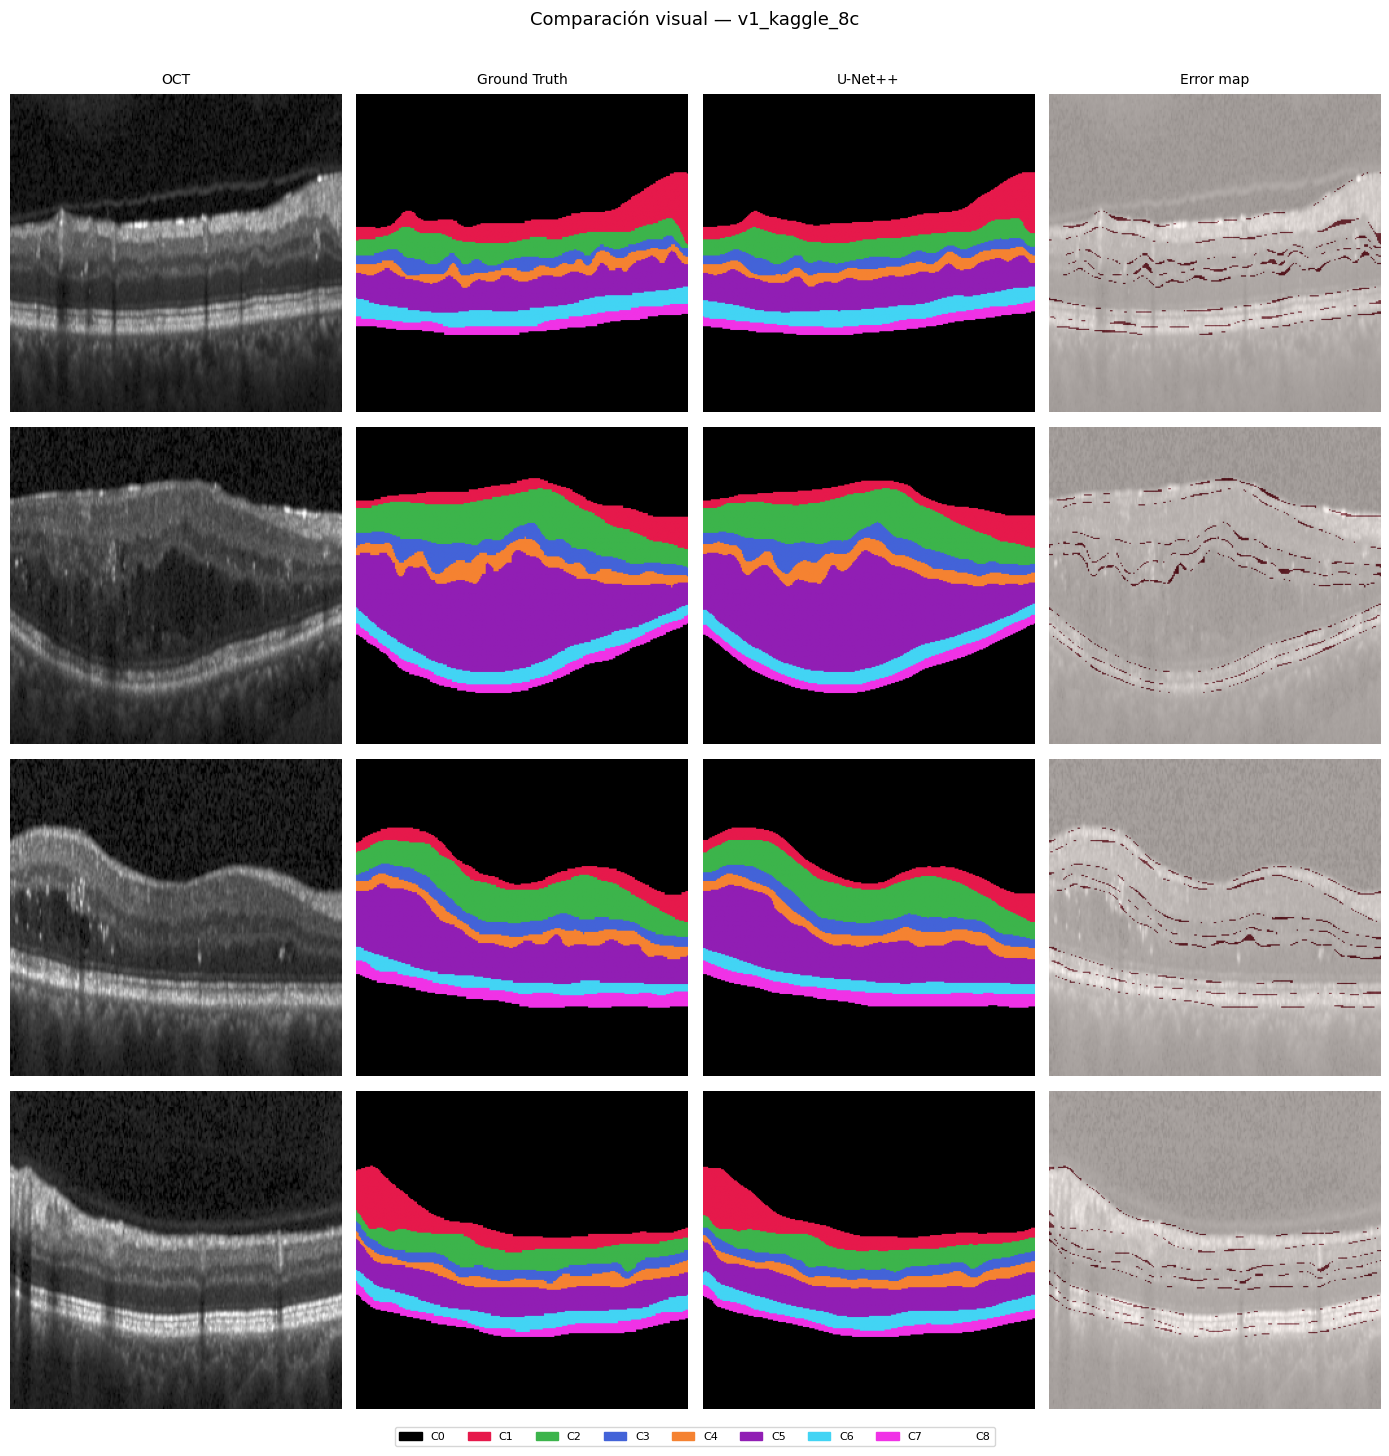

[OK] comparacion_v1_kaggle_8c.png
[SKIP] No hay predicciones para v2_duke_8c
[SKIP] No hay predicciones para v3_kaggle_duke_8c
[SKIP] No hay predicciones para v4_oct500_6c
[SKIP] No hay predicciones para v5_all_6c


In [3]:
def plot_model_comparison(variant_name, n_classes, sample_indices=None):
    """
    Para una variante, muestra una grilla:
    Filas = muestras, Columnas = OCT / GT / U-Net / U-Net++ / ResNet / SegFormer / Error
    """
    cmap = cmap9 if n_classes == 9 else cmap7
    models = ['unet', 'unetpp', 'resnet_unet', 'segformer']

    # Recolectar predicciones disponibles
    available = {m: preds_store.get(f'{m}__{variant_name}') for m in models}
    available = {m: v for m, v in available.items() if v is not None}
    if not available:
        print(f'[SKIP] No hay predicciones para {variant_name}'); return

    # Tomar un modelo como referencia para las imagenes y GT
    ref_key = list(available.keys())[0]
    imgs    = available[ref_key]['imgs']
    targets = available[ref_key]['targets']
    n_show  = 4 if sample_indices is None else len(sample_indices)
    if sample_indices is None:
        sample_indices = np.linspace(0, len(imgs)-1, n_show, dtype=int)

    n_cols = 2 + len(available) + 1  # OCT + GT + modelos + Error
    fig, axes = plt.subplots(n_show, n_cols,
                             figsize=(3.5*n_cols, 3.5*n_show))
    col_titles = ['OCT', 'Ground Truth'] + \
                 [MODEL_LABELS.get(m,m) for m in available.keys()] + ['Error map']

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, pad=8)

    for row, idx in enumerate(sample_indices):
        if idx >= len(imgs): continue
        img  = imgs[idx].astype(np.float32)
        gt   = targets[idx]
        H, W = 256, 256
        img  = cv2.resize(img, (W,H), interpolation=cv2.INTER_AREA)
        img  = ((img-img.min())/(img.max()-img.min()+1e-8))

        # Col 0: OCT
        axes[row,0].imshow(img, cmap='gray', aspect='auto')
        axes[row,0].axis('off')

        # Col 1: GT
        gt_r = cv2.resize(gt.astype(np.float32),(W,H),interpolation=cv2.INTER_NEAREST).astype(int)
        axes[row,1].imshow(gt_r, cmap=cmap, vmin=0, vmax=n_classes-1, aspect='auto')
        axes[row,1].axis('off')

        # Predicciones por modelo
        best_dice, best_col = -1, -1
        for col_off, (mname, data) in enumerate(available.items()):
            pred = data['preds'][idx] if idx < len(data['preds']) else gt
            pred_r = cv2.resize(pred.astype(np.float32),(W,H),interpolation=cv2.INTER_NEAREST).astype(int)
            axes[row, 2+col_off].imshow(pred_r, cmap=cmap, vmin=0, vmax=n_classes-1, aspect='auto')
            axes[row, 2+col_off].axis('off')
            # Calcular Dice para highlight
            dice = float(2*(pred_r==gt_r).sum()/(len(pred_r.flatten())*2+1e-8))
            axes[row, 2+col_off].set_xlabel(f'Dice={dice:.3f}', fontsize=8)
            if dice > best_dice:
                best_dice, best_col = dice, 2+col_off

        # Highlight mejor modelo
        if best_col >= 0:
            for spine in axes[row, best_col].spines.values():
                spine.set_edgecolor('lime'); spine.set_linewidth(3)

        # Col final: mapa de error (diferencia GT vs mejor modelo)
        best_model = list(available.keys())[best_col-2] if best_col >= 2 else list(available.keys())[0]
        best_pred  = cv2.resize(available[best_model]['preds'][idx].astype(np.float32),
                                (W,H),interpolation=cv2.INTER_NEAREST).astype(int)
        error_map  = (best_pred != gt_r).astype(np.float32)
        axes[row,-1].imshow(img, cmap='gray', aspect='auto')
        axes[row,-1].imshow(error_map, cmap='Reds', alpha=0.6, aspect='auto')
        axes[row,-1].axis('off')

    patches = [mpatches.Patch(color=COLORS_9[i] if n_classes==9 else COLORS_7[i],
                               label=f'C{i}') for i in range(n_classes)]
    fig.legend(handles=patches, loc='lower center', ncol=n_classes,
               bbox_to_anchor=(0.5, -0.02), fontsize=8)
    fig.suptitle(f'Comparación visual — {variant_name}', fontsize=13, y=1.01)
    plt.tight_layout()
    out = FIGS_DIR / f'comparacion_{variant_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[OK] {out.name}')

# Generar para cada variante disponible
for variant, n_cls in [('v1_kaggle_8c',9),('v2_duke_8c',9),
                        ('v3_kaggle_duke_8c',9),('v4_oct500_6c',7),('v5_all_6c',7)]:
    plot_model_comparison(variant, n_cls)

---
## 2 · Mejores y peores casos por modelo

In [4]:
def plot_best_worst(model_name, variant_name, n_classes, n_show=3):
    """Muestra los n_show mejores y n_show peores slices de un modelo."""
    key  = f'{model_name}__{variant_name}'
    data = preds_store.get(key)
    if data is None: print(f'[SKIP] {key}'); return

    cmap = cmap9 if n_classes == 9 else cmap7
    preds, targets, imgs = data['preds'], data['targets'], data['imgs']

    # Calcular Dice por slice
    dice_scores = []
    for i in range(len(preds)):
        p, t = preds[i], targets[i]
        dice = float(2*(p==t).sum()/(p.size+t.size+1e-8))
        dice_scores.append((i, dice))
    dice_scores.sort(key=lambda x: x[1])
    worst = [x[0] for x in dice_scores[:n_show]]
    best  = [x[0] for x in dice_scores[-n_show:]]

    fig, axes = plt.subplots(2*n_show, 3, figsize=(12, 4*2*n_show))
    fig.suptitle(f'{MODEL_LABELS.get(model_name,model_name)} / {variant_name}\nMejores y peores casos', fontsize=12)

    for group_idx, (indices, label) in enumerate([(best,'MEJOR'),(worst,'PEOR')]):
        for i, idx in enumerate(indices):
            row = group_idx*n_show + i
            img = cv2.resize(imgs[idx].astype(np.float32), (256,256), interpolation=cv2.INTER_AREA)
            img = (img-img.min())/(img.max()-img.min()+1e-8)
            gt  = cv2.resize(targets[idx].astype(np.float32),(256,256),interpolation=cv2.INTER_NEAREST).astype(int)
            pr  = cv2.resize(preds[idx].astype(np.float32),(256,256),interpolation=cv2.INTER_NEAREST).astype(int)
            dice = dice_scores[-(i+1)][1] if label=='MEJOR' else dice_scores[i][1]

            axes[row,0].imshow(img, cmap='gray', aspect='auto')
            axes[row,0].set_title(f'{label} #{i+1}  Dice={dice:.3f}', fontsize=9)
            axes[row,0].axis('off')

            axes[row,1].imshow(gt, cmap=cmap, vmin=0, vmax=n_classes-1, aspect='auto')
            axes[row,1].set_title('Ground Truth', fontsize=9); axes[row,1].axis('off')

            axes[row,2].imshow(pr, cmap=cmap, vmin=0, vmax=n_classes-1, aspect='auto')
            axes[row,2].set_title('Predicción', fontsize=9); axes[row,2].axis('off')

    plt.tight_layout()
    out = FIGS_DIR / f'best_worst_{model_name}_{variant_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[OK] {out.name}')

# Generar para U-Net en V5 como ejemplo principal
plot_best_worst('unet', 'v5_all_6c', 7)
plot_best_worst('segformer', 'v5_all_6c', 7)

[SKIP] unet__v5_all_6c
[SKIP] segformer__v5_all_6c


---
## 3 · Grad-CAM para SegFormer

In [5]:
# Grad-CAM: visualiza qué zonas de la imagen activa el modelo para predecir cada capa
# Requiere que el checkpoint de SegFormer esté disponible

def gradcam_segformer(variant_name, n_classes, sample_idx=0):
    ckpt_path = CKPT_DIR / 'segformer' / variant_name / 'best_overall.pth'
    if not ckpt_path.exists():
        print(f'[SKIP] Checkpoint SegFormer no encontrado: {ckpt_path}'); return

    key  = f'segformer__{variant_name}'
    data = preds_store.get(key)
    if data is None: print(f'[SKIP] No hay predicciones para {key}'); return

    from transformers import SegformerForSemanticSegmentation

    # Reconstruir modelo
    class SF(nn.Module):
        def __init__(self):
            super().__init__()
            self.model = SegformerForSemanticSegmentation.from_pretrained(
                'nvidia/segformer-b2-finetuned-ade-512-512',
                num_labels=n_classes, ignore_mismatched_sizes=True)
            old = self.model.segformer.encoder.patch_embeddings[0].proj
            self.model.segformer.encoder.patch_embeddings[0].proj = nn.Conv2d(
                1, old.out_channels, old.kernel_size, old.stride, old.padding)
        def forward(self, x):
            l = self.model(pixel_values=x).logits
            return F.interpolate(l, size=x.shape[2:], mode='bilinear', align_corners=False)

    model = SF().to(DEVICE)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # Preparar imagen
    img_np = data['imgs'][sample_idx].astype(np.float32)
    img_rs = cv2.resize(img_np, (256,256), interpolation=cv2.INTER_AREA)
    img_n  = (img_rs - img_rs.min()) / (img_rs.max()-img_rs.min()+1e-8)
    img_t  = torch.from_numpy(img_n).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    img_t.requires_grad_(True)

    # Grad-CAM: gradiente de la clase predicha respecto a la entrada
    out  = model(img_t)                          # (1, n_classes, H, W)
    pred = out.argmax(dim=1)                     # clase predicha por pixel

    # Activar para las clases 1..n_classes-2 (capas retinales, no fondos)
    cmap = cmap9 if n_classes == 9 else cmap7
    n_layers = n_classes - 2
    fig, axes = plt.subplots(2, n_layers//2+1, figsize=(4*(n_layers//2+1), 8))
    axes = axes.flatten()

    axes[0].imshow(img_n, cmap='gray'); axes[0].set_title('OCT original'); axes[0].axis('off')

    for c in range(1, n_classes-1):
        if img_t.grad is not None: img_t.grad.zero_()
        score = out[0, c].sum()
        score.backward(retain_graph=True)
        grad = img_t.grad.detach().cpu().numpy()[0,0]
        cam  = np.abs(grad)
        cam  = (cam - cam.min()) / (cam.max()-cam.min()+1e-8)
        ax = axes[c]
        ax.imshow(img_n, cmap='gray')
        ax.imshow(cam, cmap='jet', alpha=0.5)
        ax.set_title(f'Capa {c}', fontsize=9); ax.axis('off')

    plt.suptitle(f'Grad-CAM SegFormer — {variant_name}', fontsize=12)
    plt.tight_layout()
    out_path = FIGS_DIR / f'gradcam_segformer_{variant_name}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[OK] {out_path.name}')
    del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Generar Grad-CAM para V5
gradcam_segformer('v5_all_6c', n_classes=7)

[SKIP] Checkpoint SegFormer no encontrado: C:\Users\User\oct-retina-segmentation\OCT\VC2\TP_vision_por_computadora_2\checkpoints\segformer\v5_all_6c\best_overall.pth


---
## 4 · CNN vs Transformer — casos donde uno supera al otro

In [6]:
def plot_cnn_vs_transformer(variant_name, n_classes, n_show=3):
    """
    Encuentra slices donde SegFormer supera a U-Net y viceversa.
    Util para la discusion de trade-offs en la tesis.
    """
    key_unet = f'unet__{variant_name}'
    key_sf   = f'segformer__{variant_name}'
    d_unet   = preds_store.get(key_unet)
    d_sf     = preds_store.get(key_sf)

    if d_unet is None or d_sf is None:
        print(f'[SKIP] Faltan predicciones para {variant_name}'); return

    cmap = cmap9 if n_classes == 9 else cmap7
    n    = min(len(d_unet['preds']), len(d_sf['preds']))

    diffs = []
    for i in range(n):
        t = d_unet['targets'][i]
        d_u = float(2*(d_unet['preds'][i]==t).sum()/(d_unet['preds'][i].size+t.size+1e-8))
        d_s = float(2*(d_sf['preds'][i]==t).sum()/(d_sf['preds'][i].size+t.size+1e-8))
        diffs.append((i, d_u, d_s, d_s-d_u))

    sf_wins  = sorted(diffs, key=lambda x: x[3], reverse=True)[:n_show]
    cnn_wins = sorted(diffs, key=lambda x: x[3])[:n_show]

    for group, label in [(sf_wins,'SegFormer supera a U-Net'),
                          (cnn_wins,'U-Net supera a SegFormer')]:
        fig, axes = plt.subplots(len(group), 4, figsize=(16, 4*len(group)))
        if len(group) == 1: axes = axes[np.newaxis,:]
        fig.suptitle(f'{label} — {variant_name}', fontsize=12)

        for row, (idx, d_u, d_s, diff) in enumerate(group):
            img = cv2.resize(d_unet['imgs'][idx].astype(np.float32),(256,256),interpolation=cv2.INTER_AREA)
            img = (img-img.min())/(img.max()-img.min()+1e-8)
            gt  = cv2.resize(d_unet['targets'][idx].astype(np.float32),(256,256),interpolation=cv2.INTER_NEAREST).astype(int)
            pu  = cv2.resize(d_unet['preds'][idx].astype(np.float32),(256,256),interpolation=cv2.INTER_NEAREST).astype(int)
            ps  = cv2.resize(d_sf['preds'][idx].astype(np.float32),(256,256),interpolation=cv2.INTER_NEAREST).astype(int)

            axes[row,0].imshow(img, cmap='gray', aspect='auto')
            axes[row,0].set_title(f'OCT (slice {idx})', fontsize=9); axes[row,0].axis('off')
            axes[row,1].imshow(gt, cmap=cmap, vmin=0, vmax=n_classes-1, aspect='auto')
            axes[row,1].set_title('Ground Truth', fontsize=9); axes[row,1].axis('off')
            axes[row,2].imshow(pu, cmap=cmap, vmin=0, vmax=n_classes-1, aspect='auto')
            axes[row,2].set_title(f'U-Net  Dice={d_u:.3f}', fontsize=9); axes[row,2].axis('off')
            axes[row,3].imshow(ps, cmap=cmap, vmin=0, vmax=n_classes-1, aspect='auto')
            axes[row,3].set_title(f'SegFormer  Dice={d_s:.3f}  (Δ={diff:+.3f})', fontsize=9)
            axes[row,3].axis('off')

        plt.tight_layout()
        fname = 'sf_wins' if 'SegFormer' in label else 'cnn_wins'
        out = FIGS_DIR / f'{fname}_{variant_name}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'[OK] {out.name}')

plot_cnn_vs_transformer('v5_all_6c', 7)
plot_cnn_vs_transformer('v3_kaggle_duke_8c', 9)

[SKIP] Faltan predicciones para v5_all_6c
[SKIP] Faltan predicciones para v3_kaggle_duke_8c


---
## 5 · Resumen de figuras generadas

In [7]:
print('=== FIGURAS GENERADAS PARA LA TESIS ===')
for f in sorted(FIGS_DIR.glob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<50} {size_kb:>7.0f} KB')

print(f'\n  Directorio: {FIGS_DIR}')
print('\n  PIPELINE COMPLETO:')
print('  00_analisis            → EDA de los 3 datasets')
print('  01_preparacion_datasets → 5 variantes .npy')
print('  02a-d_train_*          → Entrenamiento 4 modelos × 5 variantes')
print('  03_evaluacion          → Metricas + inter-rater + inferencia')
print('  04_resultados          → Tablas + graficos + Wilcoxon')
print('  05_visualizacion       → Figuras para publicacion ← estás aquí')

=== FIGURAS GENERADAS PARA LA TESIS ===
  comparacion_v1_kaggle_8c.png                          1993 KB
  curvas_aprendizaje.png                                  47 KB
  mono_vs_multi.png                                       47 KB
  tradeoff_scatter.png                                    43 KB

  Directorio: C:\Users\User\oct-retina-segmentation\OCT\VC2\TP_vision_por_computadora_2\figures

  PIPELINE COMPLETO:
  00_analisis            → EDA de los 3 datasets
  01_preparacion_datasets → 5 variantes .npy
  02a-d_train_*          → Entrenamiento 4 modelos × 5 variantes
  03_evaluacion          → Metricas + inter-rater + inferencia
  04_resultados          → Tablas + graficos + Wilcoxon
  05_visualizacion       → Figuras para publicacion ← estás aquí
